## Baseline versus Tree Model

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV

import pandas as pd
import math

import matplotlib.pyplot as plt
import seaborn as sns

housing_bundle = fetch_california_housing()


X, y = housing_bundle.data, housing_bundle.target

dfCalifornia = pd.DataFrame(X, columns=housing_bundle.feature_names)

print(dfCalifornia.isna().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


What X represents
MedInc: Median income,
HouseAge: Median house age,
AveRooms: Average number of rooms,
AveBedrms: Average number of bedrooms,
Population: Block group population,
AveOccup: Average household occupancy,
Latitude: Geographic latitude,
Longitude: Geographic longitude.

In [ ]:
X

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8))

What y represents,
MedHouseVal: The median house value for the block group, measured in hundreds of thousands of dollars ($100,000).

In [ ]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

dfCalifornia

## Linear Regression

In [ ]:
lrModel = LinearRegression()

lrModel.fit(X_train_scaled, y_train)

y_pred_lr = lrModel.predict(X_test_scaled)

In [ ]:
rmse_lr = math.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f"RMSE: {rmse_lr}")
print(f"R2 Score: {r2_lr}")
print(f"MAE Score: {mae_lr}")

RMSE: 0.7455813830127763
R2 Score: 0.575787706032451
MAE Score: 0.5332001304956565


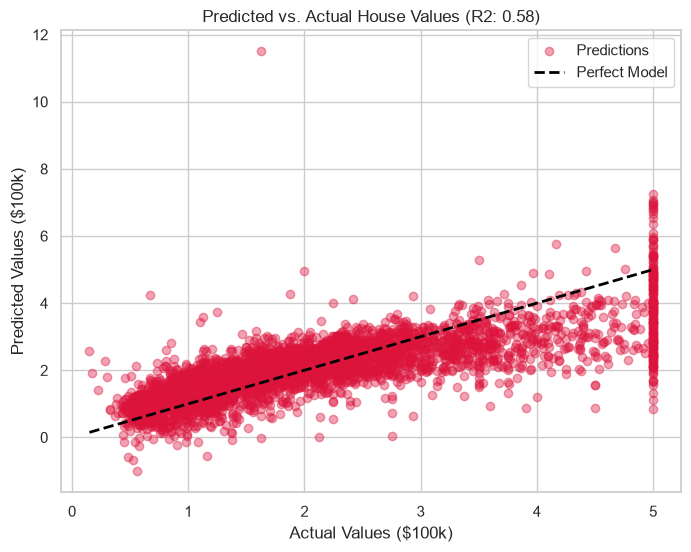

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.4, color="crimson", label="Predictions")

perfect_line = [min(y_test), max(y_test)]
plt.plot(perfect_line, perfect_line, color="black", linestyle="--", linewidth=2, label="Perfect Model")

plt.xlabel("Actual Values ($100k)")
plt.ylabel("Predicted Values ($100k)")
plt.title(f"Predicted vs. Actual House Values (R2: {r2_lr:.2f})")
plt.legend()
plt.show()

## Random Forest

In [ ]:
rfModel = RandomForestRegressor(n_estimators=450, random_state=42, n_jobs=-1)
rfModel.fit(X_train_scaled, y_train)
y_pred_rf = rfModel.predict(X_test_scaled)

In [ ]:
rmse_rf = math.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"MSE: {rmse_rf}")
print(f"R2 Score: {r2_rf}")
print(f"MAE Score: {mae_rf}")

MSE: 0.5025067497151046
R2 Score: 0.8073021188787842
MAE Score: 0.32605458963716627


MSE should be near zero, and R2 should be near 1.

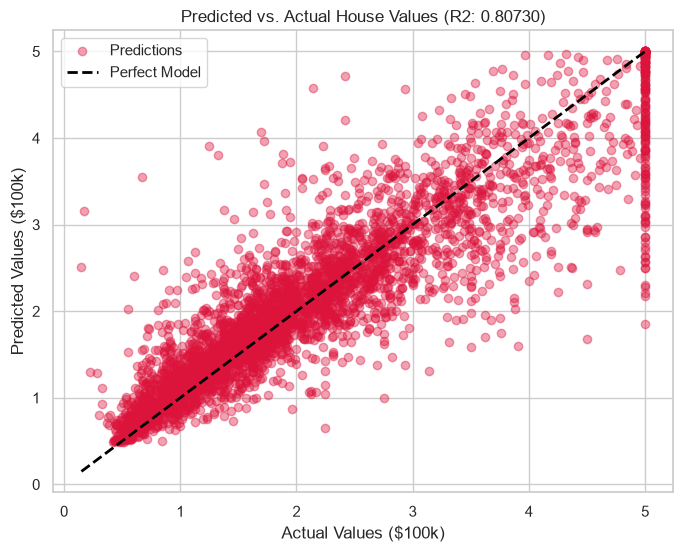

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.4, color="crimson", label="Predictions")

perfect_line = [min(y_test), max(y_test)]
plt.plot(perfect_line, perfect_line, color="black", linestyle="--", linewidth=2, label="Perfect Model")

plt.xlabel("Actual Values ($100k)")
plt.ylabel("Predicted Values ($100k)")
plt.title(f"Predicted vs. Actual House Values (R2: {r2_rf:.5f})")
plt.legend()
plt.show()

In [ ]:
print(f"Does RF beat Linear Regression? {rmse_rf < rmse_lr}")

Does RF beat Linear Regression? True


## Feature Engineering

In [ ]:
dfCalifornia.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='str')

In [ ]:
dfCalifornia["BedroomsPerRoom"] = dfCalifornia["AveBedrms"] / dfCalifornia["AveRooms"]

dfCalifornia["RoomsPerOccupant"] = dfCalifornia["AveRooms"] / dfCalifornia["AveOccup"]

dfCalifornia.info()
dfCalifornia.describe()
dfCalifornia.head()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MedInc            20640 non-null  float64
 1   HouseAge          20640 non-null  float64
 2   AveRooms          20640 non-null  float64
 3   AveBedrms         20640 non-null  float64
 4   Population        20640 non-null  float64
 5   AveOccup          20640 non-null  float64
 6   Latitude          20640 non-null  float64
 7   Longitude         20640 non-null  float64
 8   BedroomsPerRoom   20640 non-null  float64
 9   RoomsPerOccupant  20640 non-null  float64
dtypes: float64(10)
memory usage: 1.6 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,BedroomsPerRoom,RoomsPerOccupant
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,0.146591,2.732919
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,0.155797,2.956685
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,0.129516,2.957661
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,0.184458,2.283154
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,0.172096,2.879646


In [ ]:
# updating X
X_new = dfCalifornia.values

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_new, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled2 = scaler.fit_transform(X_train2)
X_test_scaled2 = scaler.transform(X_test2)

In [ ]:
lrModel.fit(X_train_scaled2, y_train2)

y_pred_lr2 = lrModel.predict(X_test_scaled2)

In [ ]:
rmse_lr2 = math.sqrt(mean_squared_error(y_test2, y_pred_lr2))
r2_lr2 = r2_score(y_test2, y_pred_lr2)
mae_lr2 = mean_absolute_error(y_test2, y_pred_lr2)

print(f"RMSE: {rmse_lr2}")
print(f"R2 Score: {r2_lr2}")
print(f"MAE Score: {mae_lr2}")

RMSE: 0.675347242463118
R2 Score: 0.6519453808117215
MAE Score: 0.4861644025414968


In [ ]:
rfModel.fit(X_train_scaled2, y_train2)

y_pred_rf2 = rfModel.predict(X_test_scaled2)

In [ ]:
rmse_rf2 = math.sqrt(mean_squared_error(y_test2, y_pred_rf2))
r2_rf2 = r2_score(y_test2, y_pred_rf2)
mae_rf2 = mean_absolute_error(y_test2, y_pred_rf2)

print(f"MSE: {rmse_rf2 < rmse_rf}")
print(f"R2 Score: {r2_rf2 > r2_rf}")
print(f"MAE Score: {mae_rf2 > mae_rf}")

MSE: True
R2 Score: True
MAE Score: 0.3262314985303619
